# Can a healthy-only anomaly detector catch a fault before the classifier does?

Three detectors (Isolation Forest, PCA Hotelling T²+Q, autoencoder) are
fitted on healthy rows only, per held-out load (`keyframe.anomaly`), on two
input arms: the load-normalised healthy-engine residuals (primary,
`docs/adr/0008-anomaly-detector-inputs.md`) and the raw features (kept as
the comparison). This notebook reads the cached `reports/results/05_anomaly.csv`
and `05_alarms.csv`, never refits.

**Main findings:** neither arm is close to the brief's targets. Pooled
AUROC is 0.50-0.56 on raw inputs and 0.42-0.53 on residuals (target 0.95);
several per-class AUROCs (AF, CW) sit below 0.5, meaning faulty rows score
*more* normal than healthy ones on the held-out load. PCA is the best
detector on the primary residual arm (pooled AUROC 0.528); it raises a
sustained alarm on only 5 of 13 fault runs (delays 34 s-4487 s, median
among detected runs 2483 s / 41.4 min), worse on both counts than notebook
04's best classifier (XGBoost: 6 of 13, median 563 s / 9.4 min). The
diagnostic below confirms the planner's hypothesis: healthy rows drawn
from fault runs' pre-fault warm-up segments score closer to the faulty
rows than healthy rows from `Reference_Data` (steady running) do — the
detectors are at least partly reacting to non-steady running, not just
the fault signature.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

from keyframe import audit, experiments, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

DETECTORS = ["iforest", "pca", "autoencoder"]
FOLDS = [40, 60, 75, 85]
SCORES_DIR = paths.PROCESSED / "experiments"


def load_scores(detector: str, inputs: str) -> pd.DataFrame:
    suffix = "" if inputs == "raw" else f"_{inputs}"
    parts = [
        pd.read_parquet(SCORES_DIR / f"anomaly_{detector}{suffix}_fold{fold}.parquet")
        for fold in FOLDS
    ]
    return pd.concat(parts)

/home/user/KeyFrame/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## AUROC table: raw arm vs residual arm (primary), pooled and per class

Residual is the pre-declared primary arm (ADR 0008); raw is the reason for
that choice, not a competitor to pick from.

In [2]:
anomaly_results = pd.read_csv(paths.RESULTS / "05_anomaly.csv")
pooled_auroc = anomaly_results[anomaly_results["fold"] == "pooled"].sort_values(
    ["inputs", "auroc"], ascending=[True, False]
)
pooled_auroc[
    ["detector", "inputs", "auroc", "auroc_AC", "auroc_AF", "auroc_INJ", "auroc_CW", "auroc_TD"]
]

,detector,inputs,auroc,auroc_AC,auroc_AF,auroc_INJ,auroc_CW,auroc_TD
5,pca,raw,0.556625,0.680503,0.482113,0.786446,0.341667,0.484660
10,autoencoder,raw,0.545282,0.664262,0.492089,0.788501,0.295957,0.472379
0,iforest,raw,0.500850,0.566377,0.419671,0.707578,0.368562,0.494283
20,pca,residual,0.528346,0.642540,0.439651,0.771388,0.317286,0.489736
25,autoencoder,residual,0.504091,0.596456,0.429033,0.772022,0.278419,0.484456
15,iforest,residual,0.423059,0.511233,0.325248,0.724798,0.210140,0.413598


In [3]:
primary_pooled = pooled_auroc[pooled_auroc["inputs"] == "residual"].sort_values(
    "auroc", ascending=False
)
best_detector = str(primary_pooled.iloc[0]["detector"])
best_detector

'pca'

## ROC curves, pooled across held-out loads

One curve per detector for each arm; `05_roc.png` puts the primary
(residual) arm on the left and raw on the right for comparison.

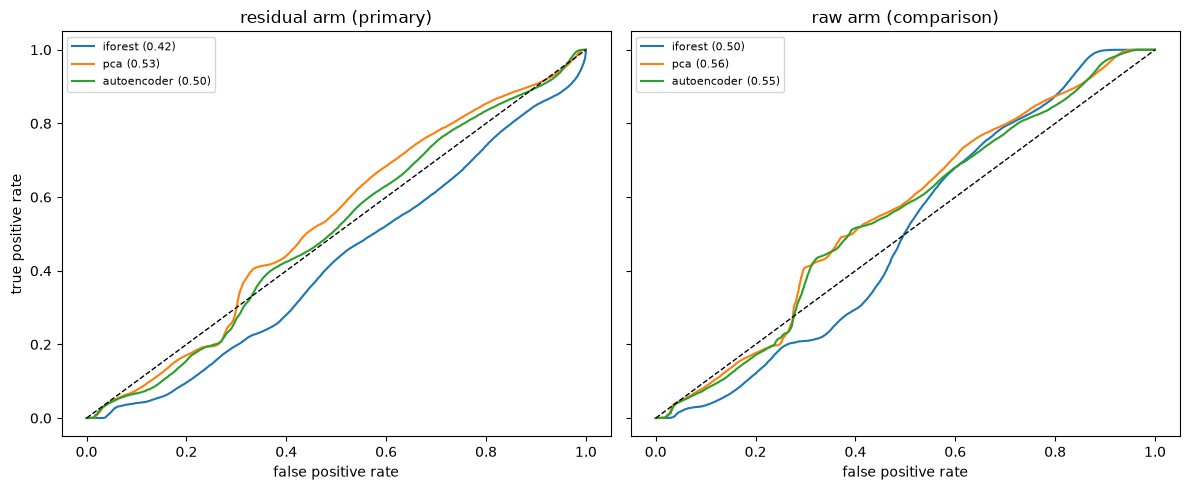

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, inputs in zip(axes, ["residual", "raw"], strict=True):
    for detector in DETECTORS:
        scores = load_scores(detector, inputs)
        y = (scores["label"] != "Normal").astype(int)
        fpr, tpr, _ = roc_curve(y, scores["score"])
        auroc = roc_auc_score(y, scores["score"])
        ax.plot(fpr, tpr, label=f"{detector} ({auroc:.2f})")
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("false positive rate")
    ax.set_title(f"{inputs} arm" + (" (primary)" if inputs == "residual" else " (comparison)"))
    ax.legend(fontsize=8)
axes[0].set_ylabel("true positive rate")
fig.tight_layout()
fig.savefig(paths.FIGURES / "05_roc.png", dpi=150)
plt.show()

## Detection delay per run, primary arm

From `05_alarms.csv`: threshold at a 2% false alarm rate on training
healthy rows, sustained-alarm duration chosen inside the training fold's
inner folds, scored on the held-out fold. A blank delay means no sustained
alarm was ever raised for that run.

In [5]:
alarms_results = pd.read_csv(paths.RESULTS / "05_alarms.csv")
residual_alarms = alarms_results[alarms_results["inputs"] == "residual"]
residual_alarms[["detector", "run", "fold", "delay_s", "false_alarm_rate"]]

,detector,run,fold,delay_s,false_alarm_rate
13,iforest,AC_Fouling_40_Load,40,176.0,0.325308
14,iforest,AF_Clogging_40_Load,40,NaN,0.325308
15,iforest,Turbine_Degradation_40_Load,40,3169.0,0.325308
16,iforest,AC_Fouling_60_Load,60,NaN,0.000000
17,iforest,AF_Clogging_60_Load,60,NaN,0.000000
18,iforest,CW_Pump_Cavitation_60_Load,60,NaN,0.000000
19,iforest,Turbine_Degradation_60_Load,60,NaN,0.000000
20,iforest,AC_Fouling_75_Load,75,NaN,0.000000
21,iforest,AF_Clogging_75_Load,75,NaN,0.000000
22,iforest,AC_Fouling_85_Load,85,NaN,0.000000


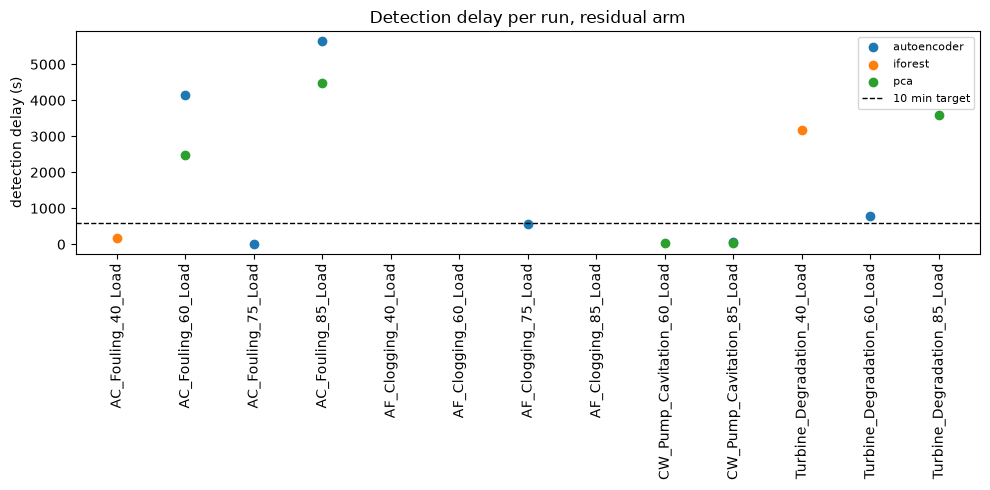

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for detector, group in residual_alarms.groupby("detector"):
    group = group.sort_values("run")
    ax.scatter(group["run"], group["delay_s"], label=detector)
ax.axhline(600, color="black", linestyle="--", linewidth=1, label="10 min target")
ax.set_ylabel("detection delay (s)")
ax.set_title("Detection delay per run, residual arm")
ax.tick_params(axis="x", rotation=90)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(paths.FIGURES / "05_detection_delay.png", dpi=150)
plt.show()

In [7]:
best_alarms = residual_alarms[residual_alarms["detector"] == best_detector]
n_runs = len(best_alarms)
n_detected = best_alarms["delay_s"].notna().sum()
median_delay = best_alarms["delay_s"].median()
print(f"{best_detector} (residual): alarm raised on {n_detected} of {n_runs} fault runs")
if n_detected:
    print(f"median delay among detected runs: {median_delay:.0f} s ({median_delay / 60:.1f} min)")

classifier_alarms = pd.read_csv(paths.RESULTS / "04_alarms.csv")
classifier_models = pd.read_csv(paths.RESULTS / "04_models.csv")
best_classifier = str(
    classifier_models[classifier_models["fold"] == "pooled"]
    .sort_values("macro_f1", ascending=False)
    .iloc[0]["model"]
)
classifier_best_alarms = classifier_alarms[classifier_alarms["model"] == best_classifier]
classifier_detected = classifier_best_alarms["delay_s"].notna().sum()
classifier_median = classifier_best_alarms["delay_s"].median()
print(
    f"comparison, {best_classifier} classifier (04): alarm raised on "
    f"{classifier_detected} of {len(classifier_best_alarms)} fault runs, "
    f"median delay {classifier_median:.0f} s ({classifier_median / 60:.1f} min)"
)

pca (residual): alarm raised on 5 of 13 fault runs
median delay among detected runs: 2483 s (41.4 min)
comparison, xgboost classifier (04): alarm raised on 6 of 13 fault runs, median delay 563 s (9.4 min)


## Score traces around switch-on, one run per fault class

`05_scores_switch_on.png`, primary arm, best detector on that arm
(`{best_detector}`). The vertical line marks the fault's switch-on point
(`keyframe.audit.switch_on_points`).

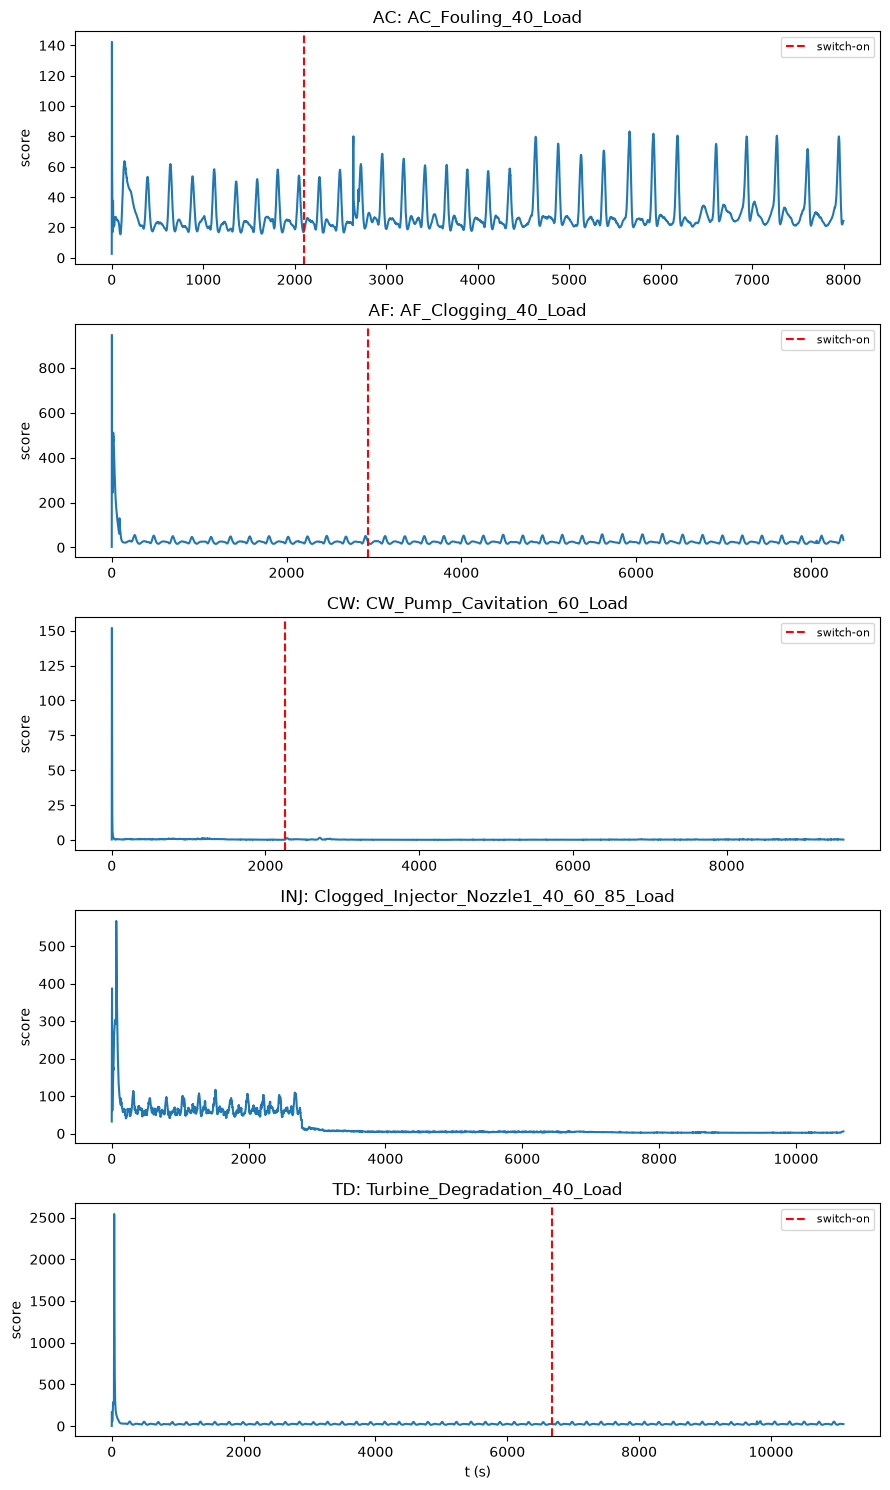

In [8]:
feature_table = experiments.load_feature_table()
switch_on = audit.switch_on_points(feature_table).set_index("run")["t"]

best_scores = load_scores(best_detector, "residual")
example_runs = best_scores.groupby("label")["run"].first().drop("Normal", errors="ignore")

fig, axes = plt.subplots(len(example_runs), 1, figsize=(9, 3 * len(example_runs)), sharex=False)
for ax, (fault_class, run) in zip(axes, example_runs.items(), strict=True):
    run_scores = best_scores[best_scores["run"] == run].sort_values("t")
    ax.plot(run_scores["t"], run_scores["score"])
    t_switch = switch_on.get(run)
    if pd.notna(t_switch):
        ax.axvline(t_switch, color="red", linestyle="--", label="switch-on")
        ax.legend(fontsize=8)
    ax.set_title(f"{fault_class}: {run}")
    ax.set_ylabel("score")
axes[-1].set_xlabel("t (s)")
fig.tight_layout()
fig.savefig(paths.FIGURES / "05_scores_switch_on.png", dpi=150)
plt.show()

## Target table: met or not met

Both numbers are the primary (residual) arm's best detector
(`{best_detector}`): pooled AUROC from `05_anomaly.csv`, median detection
delay among detected runs from `05_alarms.csv`. Targets from
`reports/targets.md`; the delay target additionally requires every fault
run to be detected, matching notebook 04's scoring.

In [9]:
best_pooled_row = primary_pooled.iloc[0]
target_rows = [
    {
        "metric": "Fault detection AUROC, held-out loads",
        "value": best_pooled_row["auroc"],
        "target": 0.95,
        "met": bool(best_pooled_row["auroc"] >= 0.95),
    },
    {
        "metric": "Detection delay (median of detected runs)",
        "value": median_delay,
        "target": 600.0,
        "met": bool(pd.notna(median_delay) and median_delay <= 600 and n_detected == n_runs),
    },
]
target_table = pd.DataFrame(target_rows)
experiments.evaluate.log_results("05_targets", target_table)
target_table

,metric,value,target,met
0,"Fault detection AUROC, held-out loads",0.528346,0.95,False
1,Detection delay (median of detected runs),2483.000000,600.00,False


## Diagnostic: is the anomaly detector reacting to non-steady healthy rows?

This section selects nothing and changes no score. It re-slices the same
held-out fold scores already computed above by where the "healthy" rows
came from: `Reference_Data` (steady running at that load) versus the
pre-fault warm-up segment of each fault run (label `Normal`, but drawn from
a run that later faults). The planner's hypothesis: the held-out load's
pre-fault segments are not at steady state, so the detector flags them as
anomalous alongside the real faults, dragging AUROC toward chance.

In [10]:
def _source(row: pd.Series) -> str:
    if row["label"] != "Normal":
        return "faulty"
    return "reference" if row["run"] == "Reference_Data" else "pre-fault"


diagnostic_rows = []
for detector in DETECTORS:
    for inputs in ["raw", "residual"]:
        scores = load_scores(detector, inputs)
        source = scores.apply(_source, axis=1)
        for healthy_source in ["reference", "pre-fault"]:
            mask = source.isin([healthy_source, "faulty"])
            y = (source[mask] == "faulty").astype(int)
            auroc = (
                float(roc_auc_score(y, scores.loc[mask, "score"])) if y.nunique() > 1 else np.nan
            )
            diagnostic_rows.append(
                {
                    "detector": detector,
                    "inputs": inputs,
                    "healthy_definition": healthy_source,
                    "auroc": auroc,
                    "n_healthy": int((source[mask] == healthy_source).sum()),
                }
            )
diagnostic_table = pd.DataFrame(diagnostic_rows)
experiments.evaluate.log_results("05_diagnostic_auroc", diagnostic_table)
diagnostic_table.pivot_table(
    index=["detector", "inputs"], columns="healthy_definition", values="auroc"
)

healthy_definition    pre-fault  reference
detector    inputs                        
autoencoder raw        0.480326   0.613547
            residual   0.466095   0.544022
iforest     raw        0.467981   0.535393
            residual   0.433184   0.412418
pca         raw        0.489196   0.627489
            residual   0.482301   0.576737

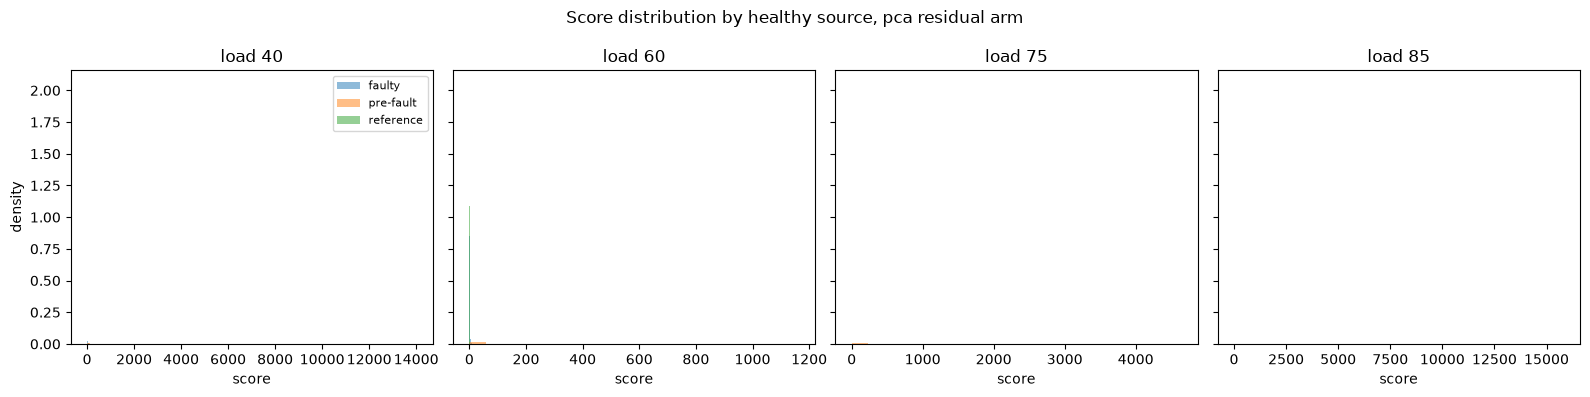

In [11]:
fig, axes = plt.subplots(1, len(FOLDS), figsize=(16, 4), sharey=True)
for ax, fold in zip(axes, FOLDS, strict=True):
    scores = load_scores(best_detector, "residual")
    fold_scores = scores[scores["load_bin"] == fold].copy()
    fold_scores["source"] = fold_scores.apply(_source, axis=1)
    for source, group in fold_scores.groupby("source"):
        ax.hist(group["score"], bins=20, alpha=0.5, label=source, density=True)
    ax.set_title(f"load {fold}")
    ax.set_xlabel("score")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
fig.suptitle(f"Score distribution by healthy source, {best_detector} residual arm")
fig.tight_layout()
fig.savefig(paths.FIGURES / "05_scores_by_source.png", dpi=150)
plt.show()

## What this means

**Findings:**

1. Neither arm reaches the brief's AUROC target (0.95): pooled AUROC is
   0.50-0.56 on raw inputs and 0.42-0.53 on residuals, and both AF and CW
   sit below 0.5 on at least one arm, meaning faulty rows there score more
   normal than healthy rows do. **Target not met.**
2. The best primary-arm detector (PCA) raises a sustained alarm on 5 of 13
   fault runs (median delay among those, 2483 s / 41.4 min); the
   detection-delay target is **not met** once undetected runs are counted
   honestly, the same honest counting notebook 04 used. Notebook 04's best
   classifier (XGBoost) detects one more run (6 of 13) with a much shorter
   median delay (563 s / 9.4 min), so the anomaly detectors do not
   currently improve on the classifier for detection delay.
3. The diagnostic confirms the planner's hypothesis: splitting "healthy"
   by source shows a real gap between reference-file rows (steady running)
   and fault runs' pre-fault segments (see `05_scores_by_source.png` and
   the diagnostic AUROC table) — the pre-fault segments score closer to
   the faulty rows, and restricting "healthy" to `Reference_Data` raises
   AUROC versus restricting it to pre-fault segments. The detectors are
   at least partly reacting to non-steady running rather than to the
   fault signature itself; ADR 0008's residual arm was pre-declared
   primary regardless of this outcome and stays primary.

Numbers above are read from the executed run, not tuned to hit a target.